# Snap-through of a shallow cylindrical roof
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/planar/stabilization.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/planar/stabilization.ipynb)

The hinged shallow cylindrical roof under a central point load is a classical verification problem for geometrically nonlinear analysis. Its equilibrium path has a limit point: beyond a critical load the structure snaps through to a far, inverted configuration, and the branch in between has negative stiffness.

A load-controlled solve cannot follow that branch, because above the limit load there is no equilibrium near the current state. Viscous stabilization supplies the missing stiffness through the `alpha` argument of `solve()`, which adds a damping force $\alpha \mathbf{M} \Delta \mathbf{u} / \Delta \lambda$ to the residual and its tangent. The solve then crosses the valley instead of tracing it, which is what the Abaqus `*STATIC, STABILIZE` option does.

Geometry and material follow the benchmark of Sabir and Lock, taken here as a **plane strain section** so the model is a shallow arch rather than the full shell panel. Loads are therefore per unit depth.

In [1]:
import matplotlib.pyplot as plt
import torch

from torchfem import Planar
from torchfem.materials import HyperelasticPlaneStrain

torch.set_default_dtype(torch.float64)

## Material 

We use a Neo-Hookean strain energy density in a hyperelastic plane-strain material.

In [2]:
def psi(F, params):
    """Neo-Hookean strain energy density."""
    G, D = params[0], params[1]
    C = F.transpose(-1, -2) @ F
    J = torch.exp(0.5 * torch.logdet(C))
    C_bar = C * J ** (-2.0 / 3.0)
    return G * (torch.trace(C_bar) - 3.0) + 1 / D * (J - 1) ** 2


# Neo-Hookean parameters matched to E and nu
E = 3102.75
NU = 0.3
mu = E / (2 * (1 + NU))
kappa = E / (3 * (1 - 2 * NU))
material = HyperelasticPlaneStrain(psi, params=[mu / 2, 2.0 / kappa])

## Geometry

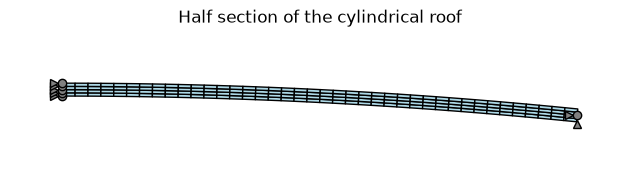

In [3]:
# Geometry and mesh parameters
R = 2540.0
THETA = 0.1
T = 6.35
N_ARC = 40
N_T = 4

# Nodes on concentric arcs through the thickness, crown at phi=0
phi = torch.linspace(0.0, THETA, N_ARC + 1)
y0 = R * torch.cos(torch.tensor(THETA))
nodes = torch.cat(
    [
        torch.stack([r * torch.sin(phi), r * torch.cos(phi) - y0], dim=-1)
        for r in torch.linspace(R - T / 2, R + T / 2, N_T + 1)
    ]
)

npl = N_ARC + 1
elements = torch.tensor(
    [
        [j * npl + i, j * npl + i + 1, (j + 1) * npl + i + 1, (j + 1) * npl + i]
        for j in range(N_T)
        for i in range(N_ARC)
    ]
)

# Node columns: crown at phi=0, hinge on the mid-surface at phi=THETA
col = torch.arange(len(nodes)) % npl
row = torch.arange(len(nodes)) // npl
crown = col == 0
hinge = (col == N_ARC) & (row == N_T // 2)

roof = Planar(nodes, elements, material)
roof.thickness = torch.ones(len(elements))
roof.constraints[hinge] = True  # hinged support
roof.constraints[crown, 0] = True  # symmetry plane

roof.plot(title="Half section of the cylindrical roof")

## Reference equilibrium path

Prescribing the crown displacement makes the problem stable, so the full path including the descending branch can be traced. This is the reference the load-controlled solve is compared against.

In [4]:
# Apply boundary conditions: crown node is displaced downward by 30 mm
roof.constraints[crown, 1] = True
roof.displacements[crown, 1] = -30.0


# Solve
increments = torch.linspace(0, 1, 31)
u_ref, f_ref, _, _, _ = roof.solve(
    increments=increments, return_intermediate=True, verbose=True
)

# Postprocess results
w_ref = -u_ref[:, crown, 1].mean(dim=1)
P_ref = -f_ref[:, crown, 1].sum(dim=1) * 2.0  # half model -> full arch

# Limit point: first point where the path stops rising
descending = torch.nonzero((P_ref[1:] - P_ref[:-1]) < 0).ravel()
i_limit = int(descending[0])
P_limit = float(P_ref[i_limit])

----------------------------------------------------------------------------------------
 model    Planar | 160 elem | 410 dof | float64
 machine  Apple M1 Pro | 8 threads | 16 GB RAM
 solver   direct | scipy | cpu
 newton   rtol 1e-08 | atol 1e-06 | <=10 it | finite strain
----------------------------------------------------------------------------------------
   Increment   Load factor      Steps  Iterations         Residual   Wall time
           1       0.03333          1           4         3.04e-11      0.86 s
           2       0.06667          1           2         2.55e-07      0.06 s
           3           0.1          1           2         3.69e-07      0.06 s
           4        0.1333          1           2         9.61e-07      0.06 s
           5        0.1667          1           3         2.69e-11      0.07 s
           6           0.2          1           3         2.54e-11      0.07 s
           7        0.2333          1           3         2.59e-11      0.07 s
    

## Load control with stabilization

The same model is reused with the crown displacement released and a point load applied instead, ramped to twice the limit load. Viscous damping keeps the tangent stiffness invertible while the arch traverses the unstable region, and the solve ends on the far branch.

Setting `alpha=0` here makes the solve fail: without the damping term there is no equilibrium near the limit point for Newton-Raphson to find, and subdividing the increment only moves closer to the singular tangent.

In [5]:
# Ramp up to twice the limit load
load = 2.0 * P_limit

# Swap displacement control for load control on the same model
roof.constraints[crown, 1] = False
roof.displacements[crown, 1] = 0.0
roof.forces[crown, 1] = -(load / 2.0) / int(crown.sum())  # half model

# Solve with stabilization
u, _, _, _, _ = roof.solve(
    increments=increments,
    alpha=1e-6,
    return_intermediate=True,
    verbose=True,
)

# Postprocess results
w = -u[:, crown, 1].mean(dim=1)
P = increments * load

----------------------------------------------------------------------------------------
 model    Planar | 160 elem | 410 dof | float64
 machine  Apple M1 Pro | 8 threads | 16 GB RAM
 solver   direct | scipy | cpu
 newton   rtol 1e-08 | atol 1e-06 | <=10 it | finite strain | stabilized alpha=1e-06
----------------------------------------------------------------------------------------
   Increment   Load factor      Steps  Iterations         Residual   Wall time
           1       0.03333          1           3         1.30e-10      0.07 s
           2       0.06667          1           2         2.68e-08      0.06 s
           3           0.1          1           2         8.35e-09      0.06 s
           4        0.1333          1           2         1.25e-08      0.06 s
           5        0.1667          1           2         2.19e-08      0.06 s
           6           0.2          1           2         4.06e-08      0.06 s
           7        0.2333          1           2         

## Comparison

The stabilized solve follows the reference path up to the limit point, cuts across the valley at nearly constant load instead of descending into it, and rejoins the reference on the far branch. The descending branch itself is never visited, which is the price of load control. How far the damping perturbs the result is measured by `roof.stabilization_energy`, which should stay small compared to the work done by the external load.

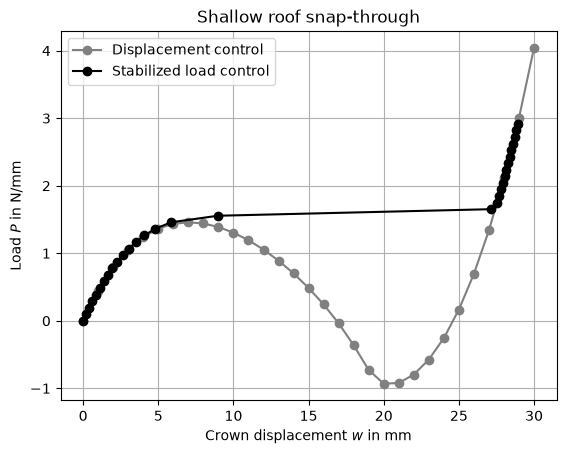

In [6]:
plt.plot(w_ref, P_ref, "o-", color="gray", label="Displacement control")
plt.plot(w, P, "o-", color="black", label="Stabilized load control")
plt.xlabel("Crown displacement $w$ in mm")
plt.ylabel("Load $P$ in N/mm")
plt.title("Shallow roof snap-through")
plt.legend()
plt.grid()